# Comparison Analysis — All KC Annotation Columns

Rafaella Sampaio de Alencar - ras555@pitt.edu

In [1]:
kc_cols = [
    "Syntax-Ontology_Expert",
    "Educational-Ontology_Expert",
    "AST_Parser",
    "Syntax-Ontology_LLM",
    "Educational-Ontology_LLM",
    "Free-Form_LLM",
]
path_output_folder = './outputs/'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from statsmodels.stats.contingency_tables import mcnemar

results = {}
for col in kc_cols:
    results[col] = pd.read_csv(os.path.join(path_output_folder, col, 'placing_records.csv'), sep='\t')

pairs = [(a, b) for i, a in enumerate(kc_cols) for b in kc_cols[i+1:]]

def highlight_max(s):
    is_max = s == s.max()
    return ['color: darkgreen' if v else '' for v in is_max]

results[kc_cols[0]].head(3)

,exercise,original_topic,assigned_topic
0,ps_hello,1,1
1,ps_python_addition,1,1
2,ps_python_swap,1,1


## Summary Metrics

In [3]:
summary_rows = []
for col in kc_cols:
    df = results[col]
    acc = (df["assigned_topic"] == df["original_topic"]).mean()
    placement = (df["assigned_topic"] != -1).mean()
    kappa = cohen_kappa_score(df["original_topic"], df["assigned_topic"])
    summary_rows.append({
        "KC Annotation": col,
        "Accuracy": round(acc, 3),
        "Placement Rate": round(placement, 3),
        "Cohen's Kappa": round(kappa, 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.apply(highlight_max, subset=["Accuracy", "Placement Rate", "Cohen's Kappa"], axis=0)

,KC Annotation,Accuracy,Placement Rate,Cohen's Kappa
0,Syntax-Ontology_Expert,0.752000,0.942000,0.730000
1,Educational-Ontology_Expert,0.789000,0.971000,0.772000
2,AST_Parser,0.731000,0.975000,0.707000
3,Syntax-Ontology_LLM,0.752000,0.946000,0.730000
4,Educational-Ontology_LLM,0.690000,0.971000,0.664000
5,Free-Form_LLM,0.562000,1.000000,0.525000


## Pairwise McNemar Tests (Accuracy)

In [4]:
pvalue_matrix = pd.DataFrame(np.nan, index=kc_cols, columns=kc_cols)

for col_a, col_b in pairs:
    merged = results[col_a].merge(results[col_b], on="exercise", suffixes=("_A", "_B"))
    correct_A = merged["assigned_topic_A"] == merged["original_topic_A"]
    correct_B = merged["assigned_topic_B"] == merged["original_topic_B"]
    table = [
        [int(np.sum(correct_A & correct_B)),  int(np.sum(correct_A & ~correct_B))],
        [int(np.sum(~correct_A & correct_B)), int(np.sum(~correct_A & ~correct_B))],
    ]
    p = mcnemar(table, exact=True).pvalue
    pvalue_matrix.loc[col_a, col_b] = round(p, 3)
    pvalue_matrix.loc[col_b, col_a] = round(p, 3)

pvalue_matrix

,Syntax-Ontology_Expert,Educational-Ontology_Expert,AST_Parser,Syntax-Ontology_LLM,Educational-Ontology_LLM,Free-Form_LLM
Syntax-Ontology_Expert,NaN,0.314,0.442,1.000,0.119,0.000
Educational-Ontology_Expert,0.314,NaN,0.130,0.321,0.000,0.000
AST_Parser,0.442,0.130,NaN,0.458,0.326,0.000
Syntax-Ontology_LLM,1.000,0.321,0.458,NaN,0.119,0.000
Educational-Ontology_LLM,0.119,0.000,0.326,0.119,NaN,0.003
Free-Form_LLM,0.000,0.000,0.000,0.000,0.003,NaN


## Head-to-Head Comparison (All Pairs)

In [5]:
h2h_rows = []
for col_a, col_b in pairs:
    merged = results[col_a].merge(results[col_b], on="exercise", suffixes=("_A", "_B"))
    correct_A = merged["assigned_topic_A"] == merged["original_topic_A"]
    correct_B = merged["assigned_topic_B"] == merged["original_topic_B"]
    placed_A  = merged["assigned_topic_A"] != -1
    placed_B  = merged["assigned_topic_B"] != -1

    a_wins = int(np.sum(correct_A & ~correct_B)) + int(np.sum(placed_A & ~placed_B))
    b_wins = int(np.sum(~correct_A & correct_B)) + int(np.sum(~placed_A & placed_B))
    tie_correct = int(np.sum(correct_A & correct_B))
    tie_wrong   = int(np.sum(~correct_A & ~correct_B))

    table = [[0, a_wins], [b_wins, 0]]
    p = mcnemar(table, exact=True).pvalue

    h2h_rows.append({
        "A": col_a, "B": col_b,
        "A wins": a_wins, "B wins": b_wins,
        "Tie correct": tie_correct, "Tie wrong": tie_wrong,
        "p-value": round(p, 3),
    })

pd.DataFrame(h2h_rows)

,A,B,A wins,B wins,Tie correct,Tie wrong,p-value
0,Syntax-Ontology_Expert,Educational-Ontology_Expert,30,46,155,24,0.085
1,Syntax-Ontology_Expert,AST_Parser,20,23,166,49,0.761
2,Syntax-Ontology_Expert,Syntax-Ontology_LLM,9,10,176,54,1.000
3,Syntax-Ontology_Expert,Educational-Ontology_LLM,51,43,134,27,0.470
4,Syntax-Ontology_Expert,Free-Form_LLM,57,25,125,49,0.001
5,Educational-Ontology_Expert,AST_Parser,50,37,147,21,0.198
6,Educational-Ontology_Expert,Syntax-Ontology_LLM,46,31,154,23,0.110
7,Educational-Ontology_Expert,Educational-Ontology_LLM,32,8,161,45,0.000
8,Educational-Ontology_Expert,Free-Form_LLM,75,27,116,31,0.000
9,AST_Parser,Syntax-Ontology_LLM,22,20,165,48,0.878


## Accuracy by Topic

In [6]:
topics = sorted(results[kc_cols[0]]["original_topic"].unique())

topic_acc_rows = []
for topic in topics:
    row = {"Topic": topic}
    for col in kc_cols:
        df = results[col]
        topic_df = df[df["original_topic"] == topic]
        row[col] = round((topic_df["assigned_topic"] == topic_df["original_topic"]).mean(), 3)
    topic_acc_rows.append(row)

topic_acc_df = pd.DataFrame(topic_acc_rows)
topic_acc_df.style.apply(highlight_max, subset=kc_cols, axis=1)

,Topic,Syntax-Ontology_Expert,Educational-Ontology_Expert,AST_Parser,Syntax-Ontology_LLM,Educational-Ontology_LLM,Free-Form_LLM
0,1,0.955000,0.955000,0.909000,0.909000,0.955000,0.773000
1,2,0.950000,1.000000,0.950000,0.850000,0.850000,0.950000
2,3,0.909000,0.000000,0.864000,0.955000,0.000000,0.591000
3,4,1.000000,1.000000,1.000000,1.000000,0.870000,1.000000
4,5,1.000000,0.917000,1.000000,1.000000,0.000000,0.917000
5,6,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
6,7,0.857000,0.929000,0.929000,0.857000,0.929000,0.857000
7,8,0.900000,0.867000,0.933000,0.933000,0.767000,0.400000
8,9,0.300000,0.400000,0.300000,0.300000,0.350000,0.000000
9,10,0.615000,0.692000,0.769000,0.769000,0.923000,0.923000


## Confusion Matrices (Normalized)

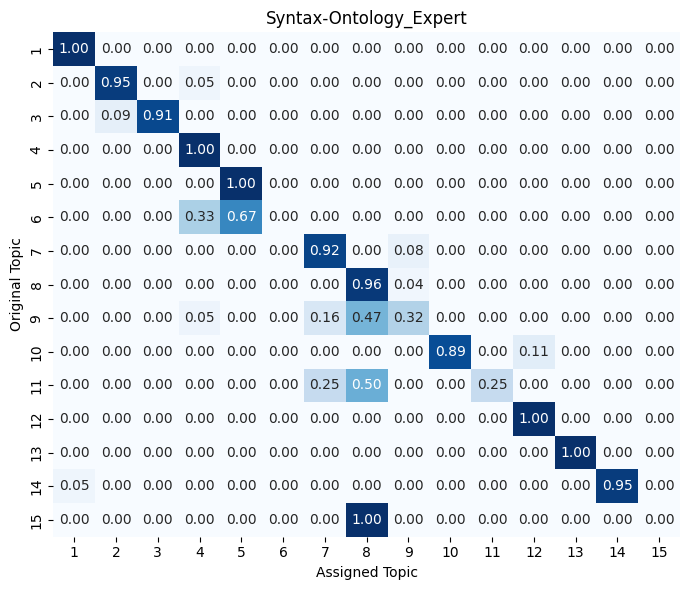

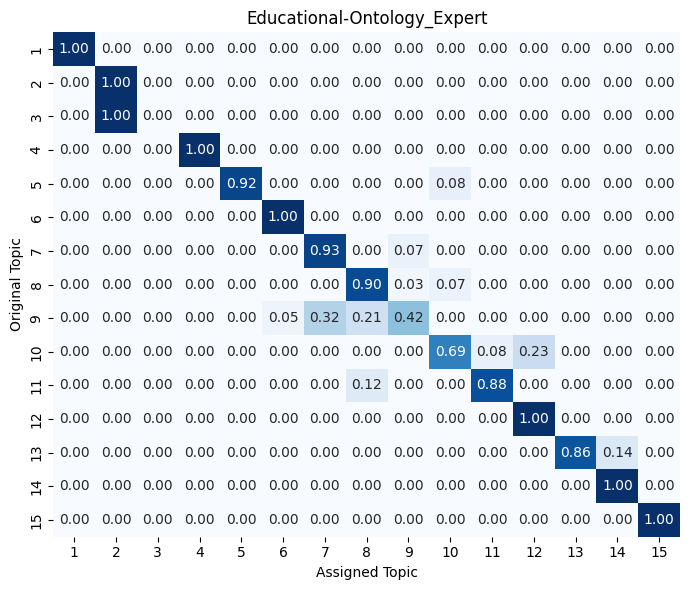

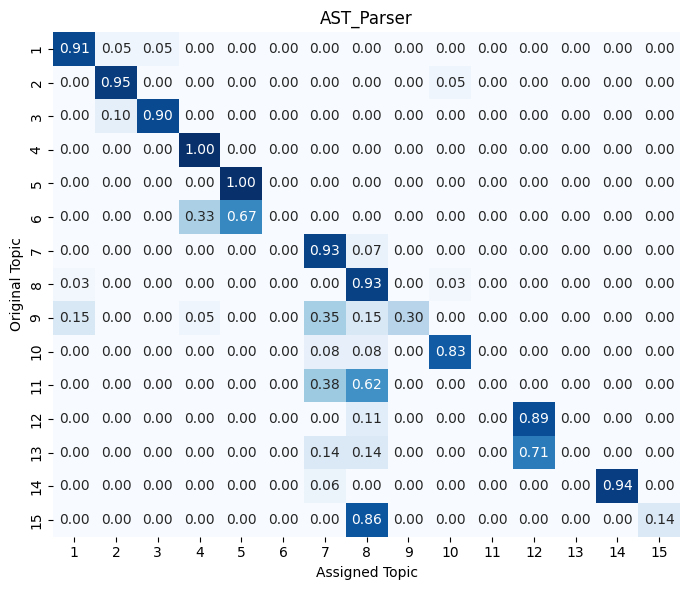

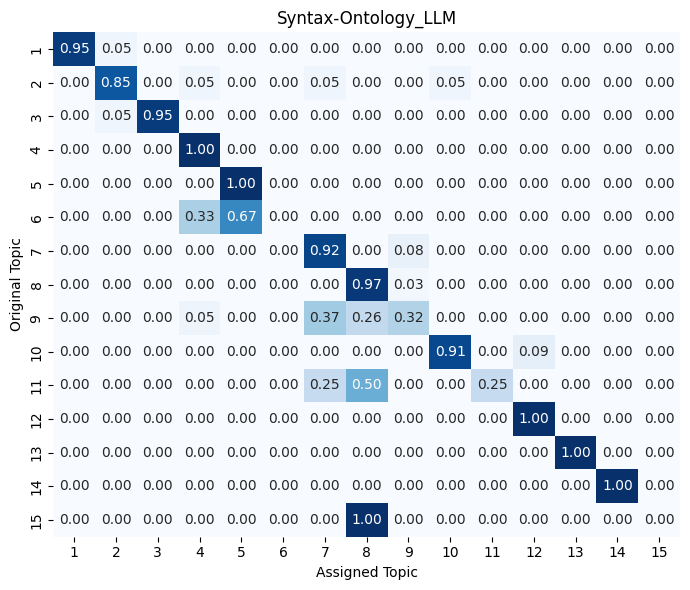

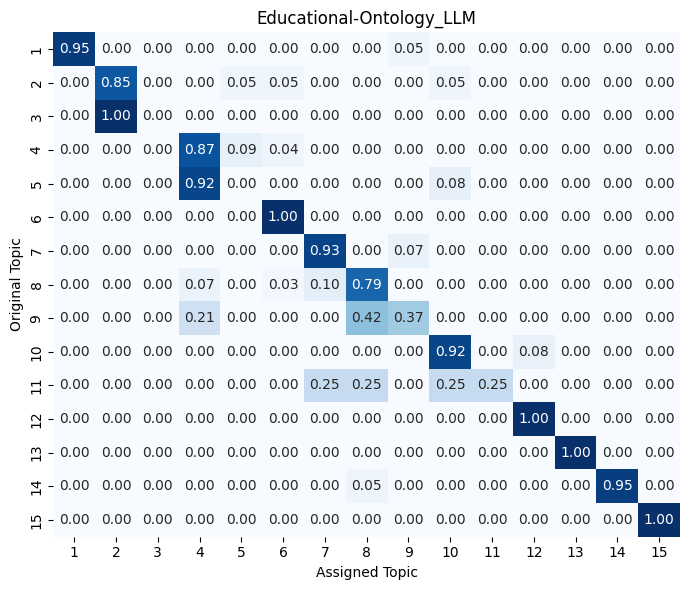

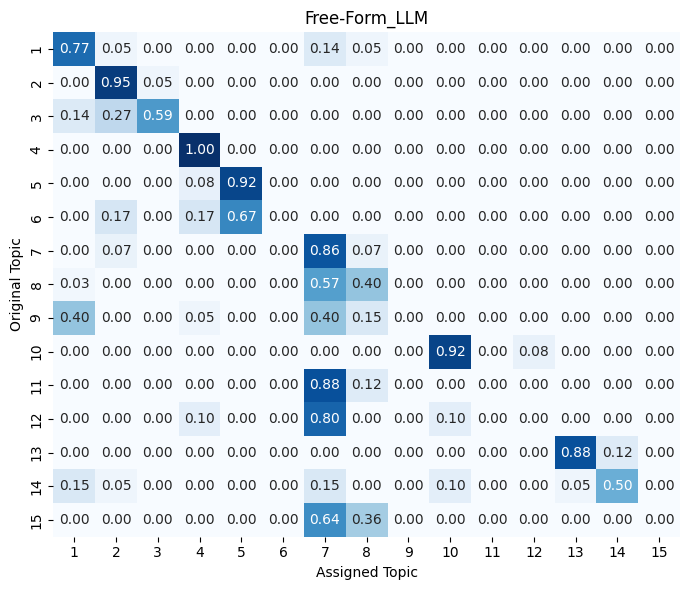

In [7]:
for col in kc_cols:
    df = results[col]
    mask = df["assigned_topic"] != -1
    cm = confusion_matrix(
        df.loc[mask, "original_topic"],
        df.loc[mask, "assigned_topic"],
        labels=topics
    )
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Save numeric versions
    os.makedirs(os.path.join(path_output_folder, "confusion_matrices_counts"), exist_ok=True)
    os.makedirs(os.path.join(path_output_folder, "confusion_matrices_normalized"), exist_ok=True)
    os.makedirs(os.path.join(path_output_folder, "confusion_matrices_normalized_images"), exist_ok=True)

    pd.DataFrame(cm, index=topics, columns=topics).to_csv(os.path.join(path_output_folder, "confusion_matrices_counts", f"{col}.csv"))
    pd.DataFrame(cm_norm, index=topics, columns=topics).round(3).to_csv(os.path.join(path_output_folder, "confusion_matrices_normalized", f"{col}.csv"))

    # Plot and save individual figure
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=topics, yticklabels=topics, ax=ax, cbar=False)
    ax.set_title(col)
    ax.set_xlabel("Assigned Topic")
    ax.set_ylabel("Original Topic")
    plt.tight_layout()
    plt.savefig(os.path.join(path_output_folder, "confusion_matrices_normalized_images", f"{col}.png"), dpi=150)
    plt.show()

## Cohen's Kappa — Original vs Assigned

In [8]:
kappa_rows = []
for col in kc_cols:
    df = results[col]
    kappa = cohen_kappa_score(df["original_topic"], df["assigned_topic"])
    kappa_rows.append({"KC Annotation": col, "Kappa (original vs assigned)": round(kappa, 3)})

pd.DataFrame(kappa_rows)

,KC Annotation,Kappa (original vs assigned)
0,Syntax-Ontology_Expert,0.730
1,Educational-Ontology_Expert,0.772
2,AST_Parser,0.707
3,Syntax-Ontology_LLM,0.730
4,Educational-Ontology_LLM,0.664
5,Free-Form_LLM,0.525


## Cohen's Kappa — Between Pairs

In [9]:
kappa_pair_rows = []
for col_a, col_b in pairs:
    merged = results[col_a].merge(results[col_b], on="exercise", suffixes=("_A", "_B"))
    kappa_ab = cohen_kappa_score(merged["assigned_topic_A"], merged["assigned_topic_B"])
    kappa_pair_rows.append({"A": col_a, "B": col_b, "Kappa (A vs B)": round(kappa_ab, 3)})

pd.DataFrame(kappa_pair_rows)

,A,B,Kappa (A vs B)
0,Syntax-Ontology_Expert,Educational-Ontology_Expert,0.680
1,Syntax-Ontology_Expert,AST_Parser,0.796
2,Syntax-Ontology_Expert,Syntax-Ontology_LLM,0.926
3,Syntax-Ontology_Expert,Educational-Ontology_LLM,0.592
4,Syntax-Ontology_Expert,Free-Form_LLM,0.545
5,Educational-Ontology_Expert,AST_Parser,0.620
6,Educational-Ontology_Expert,Syntax-Ontology_LLM,0.689
7,Educational-Ontology_Expert,Educational-Ontology_LLM,0.777
8,Educational-Ontology_Expert,Free-Form_LLM,0.484
9,AST_Parser,Syntax-Ontology_LLM,0.820
